In [9]:
# --- CELL 1: Import All Required Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, classification_report, 
                           confusion_matrix, roc_auc_score, roc_curve,
                           precision_recall_curve, average_precision_score)
from sklearn.compose import ColumnTransformer
from category_encoders import TargetEncoder
import warnings
warnings.filterwarnings('ignore')

# Bayesian Optimization
from skopt import BayesSearchCV
from skopt.space import Integer, Categorical

print("All libraries imported successfully!")

All libraries imported successfully!


In [15]:
# --- CELL 2: Load and Prepare Data ---

# Load your dataset (replace with your actual file path)
df = pd.read_csv('heart_original.csv')  # Update with your file name

# 🔥 Remove rows with NULL values
df = df.dropna()

# 🔥 Remove rows with empty strings or whitespace
df = df[(df != '').all(axis=1)]

# Display basic info
print("Dataset Shape before cleaning:", df.shape)
print("\nFirst 5 rows after cleaning:")
print(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values AFTER cleaning:")
print(df.isnull().sum())


Dataset Shape before cleaning: (301, 14)

First 5 rows after cleaning:
   Age  Sex     ChestPain  RestBP  Chol  Fbs  RestECG  MaxHR  ExAng  Oldpeak  \
0   63    1       typical     145   233    1        2    150      0      2.3   
1   67    1  asymptomatic     160   286    0        2    108      1      1.5   
2   67    1  asymptomatic     120   229    0        2    129      1      2.6   
3   37    1    nonanginal     130   250    0        0    187      0      3.5   
4   41    0    nontypical     130   204    0        2    172      0      1.4   

   Slope  Ca        Thal  Target  
0      3   0       fixed       0  
1      2   3      normal       1  
2      2   2  reversable       1  
3      3   0      normal       0  
4      1   0      normal       0  

Column names:
['Age', 'Sex', 'ChestPain', 'RestBP', 'Chol', 'Fbs', 'RestECG', 'MaxHR', 'ExAng', 'Oldpeak', 'Slope', 'Ca', 'Thal', 'Target']

Missing values AFTER cleaning:
Age          0
Sex          0
ChestPain    0
RestBP       0
Chol 

In [21]:
# --- CELL 3: Define Categorical and Numerical Columns ---
# UPDATE THESE BASED ON YOUR ACTUAL DATASET
# These are common column names from heart disease datasets - ADJUST AS NEEDED

categorical_columns = ['ChestPain','Thal']
numerical_columns = ['Age', 'Sex', 'RestBP', 'Chol', 'Fbs', 'RestECG', 'MaxHR', 'ExAng', 'Oldpeak', 'Slope', 'Ca']

# If your dataset has different column names, modify the lists above
# For example, if you have 'chest_pain_type' instead of 'cp', update accordingly

print("Categorical columns:", categorical_columns)
print("Numerical columns:", numerical_columns)
print("All columns in dataset:", df.columns.tolist())

Categorical columns: ['ChestPain', 'Thal']
Numerical columns: ['Age', 'Sex', 'RestBP', 'Chol', 'Fbs', 'RestECG', 'MaxHR', 'ExAng', 'Oldpeak', 'Slope', 'Ca']
All columns in dataset: ['Age', 'Sex', 'ChestPain', 'RestBP', 'Chol', 'Fbs', 'RestECG', 'MaxHR', 'ExAng', 'Oldpeak', 'Slope', 'Ca', 'Thal', 'Target']


In [22]:
# --- CELL 4: Base Setup for All Encoding Methods ---
# Define X and y
X = df.drop('Target', axis=1)  # Replace 'target' with your actual target column name
y = df['Target']

# Split the data FIRST (important to avoid data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")
print(f"Class distribution in training set:\n{y_train.value_counts(normalize=True)}")

Training set size: (240, 13)
Testing set size: (61, 13)
Class distribution in training set:
Target
0    0.541667
1    0.458333
Name: proportion, dtype: float64


In [23]:
# --- CELL 5: One-Hot Encoding Implementation ---
print("="*50)
print("ONE-HOT ENCODING RESULTS")
print("="*50)

# Create a copy of the data for One-Hot Encoding
X_train_oh = X_train.copy()
X_test_oh = X_test.copy()

# Apply One-Hot Encoding to categorical columns
X_train_oh = pd.get_dummies(X_train_oh, columns=categorical_columns, drop_first=True)
X_test_oh = pd.get_dummies(X_test_oh, columns=categorical_columns, drop_first=True)

# Ensure both train and test have same columns
missing_cols = set(X_train_oh.columns) - set(X_test_oh.columns)
for col in missing_cols:
    X_test_oh[col] = 0
X_test_oh = X_test_oh[X_train_oh.columns]

# Scale numerical features
scaler_oh = StandardScaler()
X_train_oh[numerical_columns] = scaler_oh.fit_transform(X_train_oh[numerical_columns])
X_test_oh[numerical_columns] = scaler_oh.transform(X_test_oh[numerical_columns])

print(f"After One-Hot Encoding - Training shape: {X_train_oh.shape}")

ONE-HOT ENCODING RESULTS
After One-Hot Encoding - Training shape: (240, 16)


In [24]:
# --- CELL 6: Label Encoding Implementation ---
print("="*50)
print("LABEL ENCODING RESULTS")
print("="*50)

# Create a copy of the data for Label Encoding
X_train_le = X_train.copy()
X_test_le = X_test.copy()

# Apply Label Encoding to categorical columns
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    X_train_le[col] = le.fit_transform(X_train_le[col].astype(str))
    X_test_le[col] = le.transform(X_test_le[col].astype(str))
    label_encoders[col] = le

# Scale numerical features
scaler_le = StandardScaler()
X_train_le[numerical_columns] = scaler_le.fit_transform(X_train_le[numerical_columns])
X_test_le[numerical_columns] = scaler_le.transform(X_test_le[numerical_columns])

print(f"After Label Encoding - Training shape: {X_train_le.shape}")

LABEL ENCODING RESULTS
After Label Encoding - Training shape: (240, 13)


In [25]:
# --- CELL 7: Target Encoding Implementation ---
print("="*50)
print("TARGET ENCODING RESULTS")
print("="*50)

# Create a copy of the data for Target Encoding
X_train_te = X_train.copy()
X_test_te = X_test.copy()

# Apply Target Encoding
target_encoder = TargetEncoder(cols=categorical_columns)
X_train_te = target_encoder.fit_transform(X_train_te, y_train)
X_test_te = target_encoder.transform(X_test_te)

# Scale numerical features
scaler_te = StandardScaler()
X_train_te[numerical_columns] = scaler_te.fit_transform(X_train_te[numerical_columns])
X_test_te[numerical_columns] = scaler_te.transform(X_test_te[numerical_columns])

print(f"After Target Encoding - Training shape: {X_train_te.shape}")

TARGET ENCODING RESULTS
After Target Encoding - Training shape: (240, 13)


In [27]:
# --- CELL 8: Decision Tree with GridSearchCV for All Encodings ---
def evaluate_model(model, X_test, y_test, model_name):
    """Helper function to evaluate and display results"""
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    avg_precision = average_precision_score(y_test, y_pred_proba)
    
    # Classification report
    report = classification_report(y_test, y_pred, output_dict=True)
    recall = report['1']['recall']
    precision = report['1']['precision']
    f1 = report['1']['f1-score']
    
    print(f"\n{model_name} Results:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"Average Precision: {avg_precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"F1-Score: {f1:.4f}")
    
    return {
        'accuracy': accuracy,
        'roc_auc': roc_auc,
        'avg_precision': avg_precision,
        'recall': recall,
        'precision': precision,
        'f1': f1,
        'model': model,
        'y_pred_proba': y_pred_proba
    }

# Define parameter grid for GridSearch
param_grid = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

results = {}

# Train with One-Hot Encoding
print("\n" + "="*50)
print("GRID SEARCH - One-Hot Encoding")
print("="*50)
dt_oh = DecisionTreeClassifier(random_state=42)
grid_search_oh = GridSearchCV(dt_oh, param_grid, cv=5, scoring='recall', n_jobs=-1)
grid_search_oh.fit(X_train_oh, y_train)
print(f"Best parameters: {grid_search_oh.best_params_}")
results['one_hot_grid'] = evaluate_model(grid_search_oh.best_estimator_, X_test_oh, y_test, "One-Hot + GridSearch")

# Train with Label Encoding
print("\n" + "="*50)
print("GRID SEARCH - Label Encoding")
print("="*50)
dt_le = DecisionTreeClassifier(random_state=42)
grid_search_le = GridSearchCV(dt_le, param_grid, cv=5, scoring='recall', n_jobs=-1)
grid_search_le.fit(X_train_le, y_train)
print(f"Best parameters: {grid_search_le.best_params_}")
results['label_grid'] = evaluate_model(grid_search_le.best_estimator_, X_test_le, y_test, "Label + GridSearch")

# Train with Target Encoding
print("\n" + "="*50)
print("GRID SEARCH - Target Encoding")
print("="*50)
dt_te = DecisionTreeClassifier(random_state=42)
grid_search_te = GridSearchCV(dt_te, param_grid, cv=5, scoring='recall', n_jobs=-1)
grid_search_te.fit(X_train_te, y_train)
print(f"Best parameters: {grid_search_te.best_params_}")
results['target_grid'] = evaluate_model(grid_search_te.best_estimator_, X_test_te, y_test, "Target + GridSearch")


GRID SEARCH - One-Hot Encoding
Best parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}

One-Hot + GridSearch Results:
Accuracy: 0.6885
ROC-AUC: 0.6991
Average Precision: 0.6016
Recall: 0.6786
Precision: 0.6552
F1-Score: 0.6667

GRID SEARCH - Label Encoding
Best parameters: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 2}

Label + GridSearch Results:
Accuracy: 0.7869
ROC-AUC: 0.8750
Average Precision: 0.8425
Recall: 0.6786
Precision: 0.8261
F1-Score: 0.7451

GRID SEARCH - Target Encoding
Best parameters: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}

Target + GridSearch Results:
Accuracy: 0.8033
ROC-AUC: 0.8728
Average Precision: 0.8171
Recall: 0.7857
Precision: 0.7857
F1-Score: 0.7857


In [28]:
# --- CELL 9: Decision Tree with Bayesian Optimization for All Encodings ---
# Define search space for Bayesian Optimization
bayes_space = {
    'max_depth': Integer(3, 20),
    'min_samples_split': Integer(2, 20),
    'min_samples_leaf': Integer(1, 10),
    'criterion': Categorical(['gini', 'entropy'])
}

# Bayesian Optimization with One-Hot Encoding
print("\n" + "="*50)
print("BAYESIAN OPTIMIZATION - One-Hot Encoding")
print("="*50)
dt_oh_bayes = DecisionTreeClassifier(random_state=42)
bayes_search_oh = BayesSearchCV(dt_oh_bayes, bayes_space, cv=5, scoring='recall', 
                               n_iter=50, random_state=42, n_jobs=-1)
bayes_search_oh.fit(X_train_oh, y_train)
print(f"Best parameters: {bayes_search_oh.best_params_}")
results['one_hot_bayes'] = evaluate_model(bayes_search_oh.best_estimator_, X_test_oh, y_test, "One-Hot + Bayesian")

# Bayesian Optimization with Label Encoding
print("\n" + "="*50)
print("BAYESIAN OPTIMIZATION - Label Encoding")
print("="*50)
dt_le_bayes = DecisionTreeClassifier(random_state=42)
bayes_search_le = BayesSearchCV(dt_le_bayes, bayes_space, cv=5, scoring='recall', 
                               n_iter=50, random_state=42, n_jobs=-1)
bayes_search_le.fit(X_train_le, y_train)
print(f"Best parameters: {bayes_search_le.best_params_}")
results['label_bayes'] = evaluate_model(bayes_search_le.best_estimator_, X_test_le, y_test, "Label + Bayesian")

# Bayesian Optimization with Target Encoding
print("\n" + "="*50)
print("BAYESIAN OPTIMIZATION - Target Encoding")
print("="*50)
dt_te_bayes = DecisionTreeClassifier(random_state=42)
bayes_search_te = BayesSearchCV(dt_te_bayes, bayes_space, cv=5, scoring='recall', 
                               n_iter=50, random_state=42, n_jobs=-1)
bayes_search_te.fit(X_train_te, y_train)
print(f"Best parameters: {bayes_search_te.best_params_}")
results['target_bayes'] = evaluate_model(bayes_search_te.best_estimator_, X_test_te, y_test, "Target + Bayesian")


BAYESIAN OPTIMIZATION - One-Hot Encoding
Best parameters: OrderedDict({'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 9, 'min_samples_split': 9})

One-Hot + Bayesian Results:
Accuracy: 0.7541
ROC-AUC: 0.8669
Average Precision: 0.8064
Recall: 0.7500
Precision: 0.7241
F1-Score: 0.7368

BAYESIAN OPTIMIZATION - Label Encoding
Best parameters: OrderedDict({'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 19})

Label + Bayesian Results:
Accuracy: 0.7869
ROC-AUC: 0.8474
Average Precision: 0.8278
Recall: 0.6786
Precision: 0.8261
F1-Score: 0.7451

BAYESIAN OPTIMIZATION - Target Encoding
Best parameters: OrderedDict({'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 9, 'min_samples_split': 9})

Target + Bayesian Results:
Accuracy: 0.8033
ROC-AUC: 0.8734
Average Precision: 0.8122
Recall: 0.7857
Precision: 0.7857
F1-Score: 0.7857


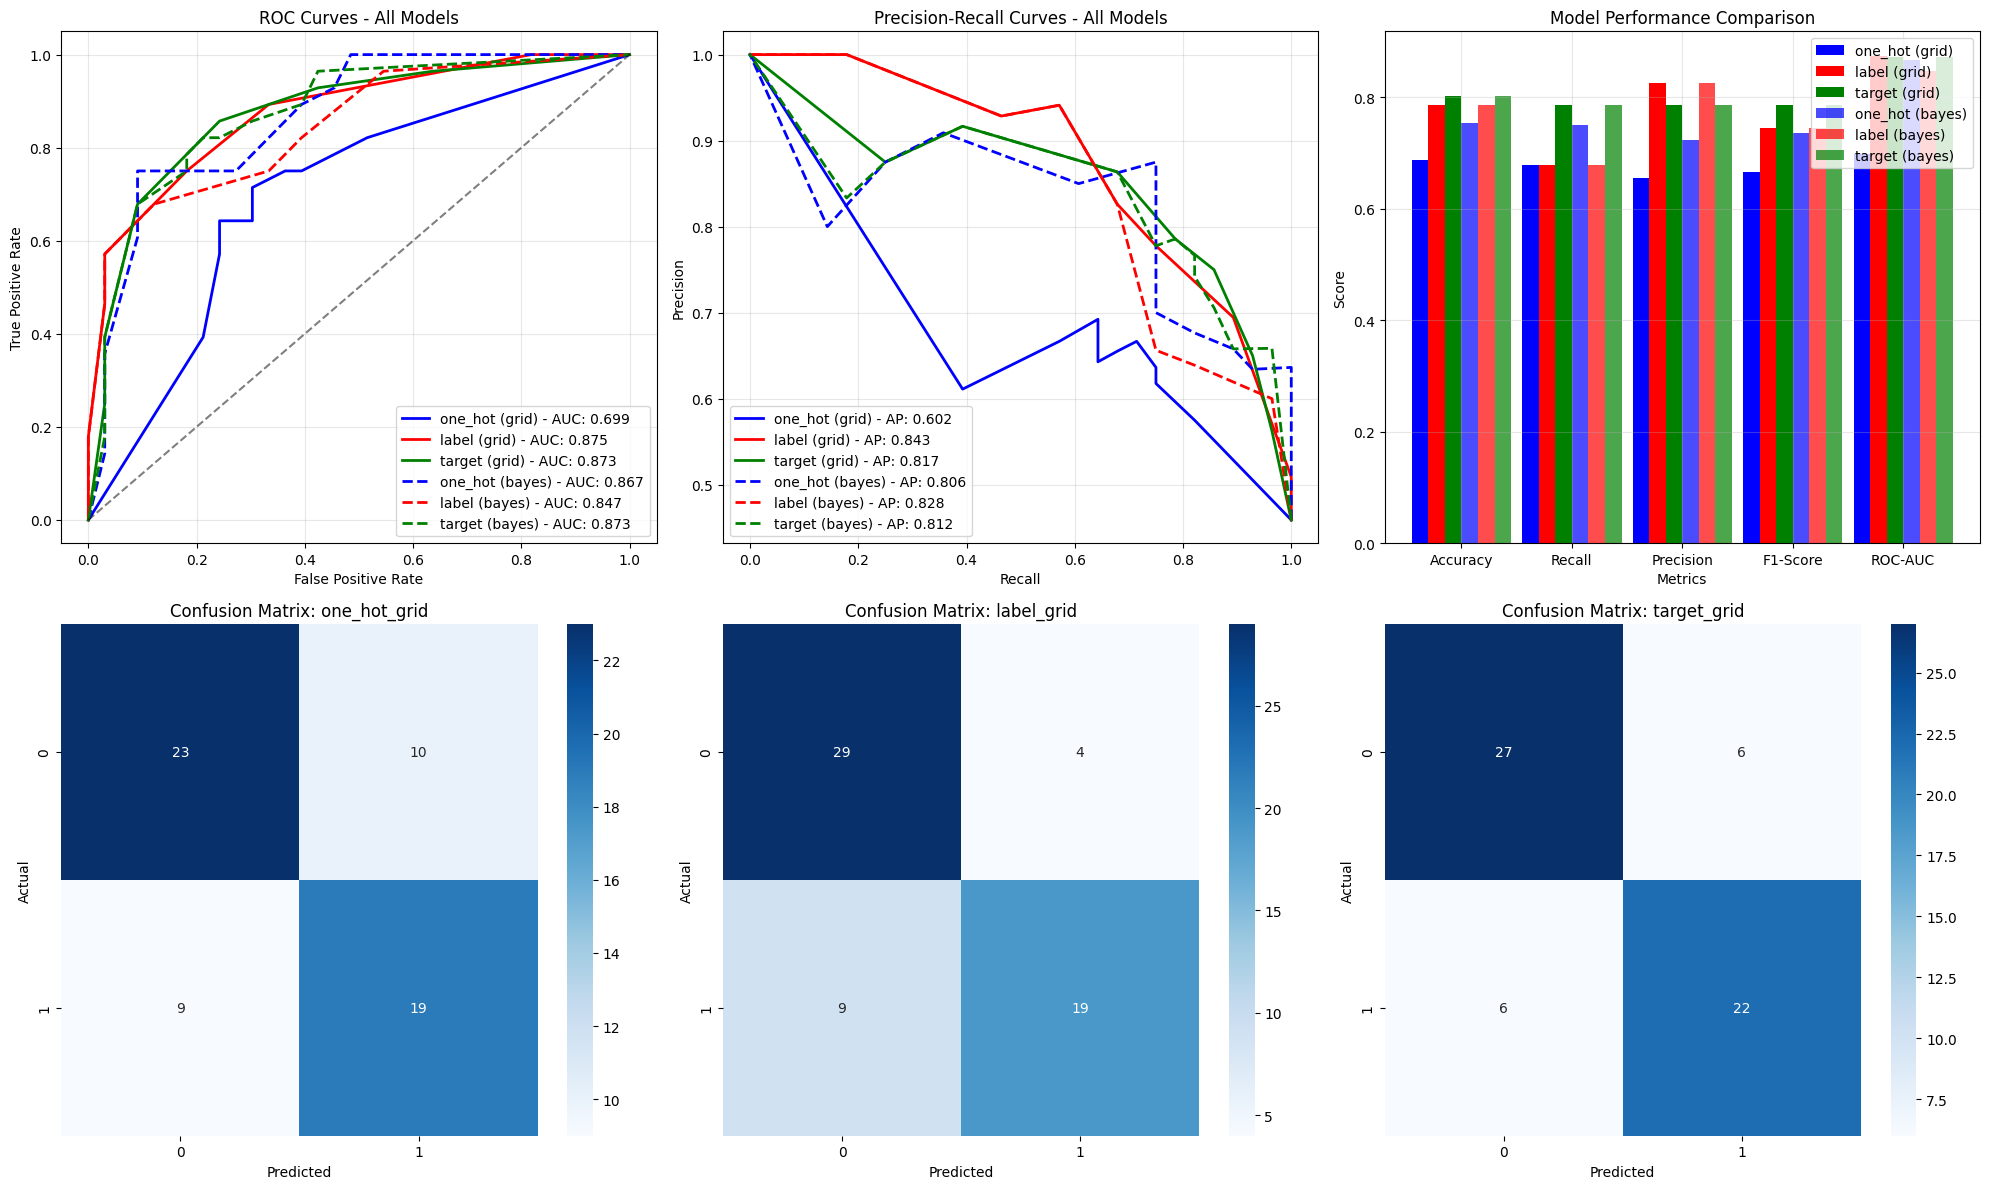

In [40]:
# --- CELL 10: Comprehensive Visualization ---
def plot_comprehensive_results(results, y_test, X_test_oh, X_test_le, X_test_te):
    """Create comprehensive visualizations for all models"""

    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    
    # Colors for different encodings
    colors = {'one_hot': 'blue', 'label': 'red', 'target': 'green'}
    
    # Mapping encoding_type to actual test sets
    X_test_dict = {
        'one_hot': X_test_oh,
        'label': X_test_le,
        'target': X_test_te
    }

    # ---------------- ROC Curves ----------------
    ax = axes[0, 0]
    for key, result in results.items():
        parts = key.split('_')
        encoding_type = '_'.join(parts[:-1])  # everything except last part
        optimization = parts[-1]              # last part is 'grid' or 'bayes'
        color = colors[encoding_type]
        linestyle = '-' if optimization == 'grid' else '--'
        
        fpr, tpr, _ = roc_curve(y_test, result['y_pred_proba'])
        roc_auc = result['roc_auc']
        
        ax.plot(fpr, tpr, color=color, linestyle=linestyle, 
                linewidth=2, label=f'{encoding_type} ({optimization}) - AUC: {roc_auc:.3f}')
    
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curves - All Models')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # ---------------- Precision-Recall Curves ----------------
    ax = axes[0, 1]
    for key, result in results.items():
        parts = key.split('_')
        encoding_type = '_'.join(parts[:-1])
        optimization = parts[-1]
        color = colors[encoding_type]
        linestyle = '-' if optimization == 'grid' else '--'
        
        precision, recall, _ = precision_recall_curve(y_test, result['y_pred_proba'])
        avg_precision = result['avg_precision']
        
        ax.plot(recall, precision, color=color, linestyle=linestyle, 
                linewidth=2, label=f'{encoding_type} ({optimization}) - AP: {avg_precision:.3f}')
    
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title('Precision-Recall Curves - All Models')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # ---------------- Metrics Comparison Bar Chart ----------------
    ax = axes[0, 2]
    metrics = ['accuracy', 'recall', 'precision', 'f1', 'roc_auc']
    metric_names = ['Accuracy', 'Recall', 'Precision', 'F1-Score', 'ROC-AUC']
    
    x = np.arange(len(metrics))
    width = 0.15
    
    for i, (key, result) in enumerate(results.items()):
        values = [result[metric] for metric in metrics]
        parts = key.split('_')
        encoding_type = '_'.join(parts[:-1])
        optimization = parts[-1]
        color = colors[encoding_type]
        alpha = 1.0 if optimization == 'grid' else 0.7
        
        ax.bar(x + i*width, values, width, label=f'{encoding_type} ({optimization})', 
               color=color, alpha=alpha)
    
    ax.set_xlabel('Metrics')
    ax.set_ylabel('Score')
    ax.set_title('Model Performance Comparison')
    ax.set_xticks(x + width*len(results)/2 - width/2)
    ax.set_xticklabels(metric_names)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # ---------------- Confusion Matrices ----------------
    for idx, (key, result) in enumerate(list(results.items())[:3]):  # max 3 to fit subplot
        ax = axes[1, idx]
        parts = key.split('_')
        encoding_type = '_'.join(parts[:-1])
        
        # Safely get corresponding test set
        X_test_key = X_test_dict[encoding_type]
        y_pred = result['model'].predict(X_test_key)
        
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
        ax.set_title(f'Confusion Matrix: {key}')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
    
    # Remove unused subplot if fewer than 3 confusion matrices
    if len(results) < 3:
        axes[1, -1].axis('off')
    
    plt.tight_layout()
    plt.show()

# ---------------- Plot all results ----------------
plot_comprehensive_results(results, y_test, X_test_oh, X_test_le, X_test_te)


In [41]:
# --- CELL 11: Results Summary and Analysis ---
print("="*70)
print("FINAL DECISION TREE ANALYSIS SUMMARY")
print("="*70)

# Create summary dataframe
summary_data = []
for key, result in results.items():
    summary_data.append({
        'Encoding': key.split('_')[0] + ' ' + key.split('_')[1],
        'Optimization': key.split('_')[-1],
        'Accuracy': f"{result['accuracy']:.4f}",
        'Recall': f"{result['recall']:.4f}",
        'Precision': f"{result['precision']:.4f}",
        'F1-Score': f"{result['f1']:.4f}",
        'ROC-AUC': f"{result['roc_auc']:.4f}",
        'Avg Precision': f"{result['avg_precision']:.4f}"
    })

summary_df = pd.DataFrame(summary_data)
print("\nDetailed Performance Summary:")
print(summary_df.to_string(index=False))

# Find best model based on Recall (most important for heart disease)
best_model_recall = max(results.items(), key=lambda x: x[1]['recall'])
best_model_f1 = max(results.items(), key=lambda x: x[1]['f1'])

print(f"\n⭐ BEST MODEL BY RECALL: {best_model_recall[0]}")
print(f"   Recall: {best_model_recall[1]['recall']:.4f}")
print(f"   F1-Score: {best_model_recall[1]['f1']:.4f}")

print(f"\n⭐ BEST MODEL BY F1-SCORE: {best_model_f1[0]}")
print(f"   F1-Score: {best_model_f1[1]['f1']:.4f}")
print(f"   Recall: {best_model_f1[1]['recall']:.4f}")

# Compare encoding methods
encoding_performance = {}
for encoding in ['one_hot', 'label', 'target']:
    encoding_results = [v for k, v in results.items() if k.startswith(encoding)]
    if encoding_results:
        avg_recall = np.mean([r['recall'] for r in encoding_results])
        encoding_performance[encoding] = avg_recall

best_encoding = max(encoding_performance.items(), key=lambda x: x[1])
print(f"\n📊 BEST ENCODING METHOD (Average Recall): {best_encoding[0]}")
print(f"   Average Recall: {best_encoding[1]:.4f}")

# Compare optimization methods
grid_results = [v for k, v in results.items() if k.endswith('grid')]
bayes_results = [v for k, v in results.items() if k.endswith('bayes')]

avg_grid_recall = np.mean([r['recall'] for r in grid_results])
avg_bayes_recall = np.mean([r['recall'] for r in bayes_results])

print(f"\n⚙️ OPTIMIZATION METHOD COMPARISON:")
print(f"   GridSearchCV Average Recall: {avg_grid_recall:.4f}")
print(f"   Bayesian Optimization Average Recall: {avg_bayes_recall:.4f}")

FINAL DECISION TREE ANALYSIS SUMMARY

Detailed Performance Summary:
    Encoding Optimization Accuracy Recall Precision F1-Score ROC-AUC Avg Precision
     one hot         grid   0.6885 0.6786    0.6552   0.6667  0.6991        0.6016
  label grid         grid   0.7869 0.6786    0.8261   0.7451  0.8750        0.8425
 target grid         grid   0.8033 0.7857    0.7857   0.7857  0.8728        0.8171
     one hot        bayes   0.7541 0.7500    0.7241   0.7368  0.8669        0.8064
 label bayes        bayes   0.7869 0.6786    0.8261   0.7451  0.8474        0.8278
target bayes        bayes   0.8033 0.7857    0.7857   0.7857  0.8734        0.8122

⭐ BEST MODEL BY RECALL: target_grid
   Recall: 0.7857
   F1-Score: 0.7857

⭐ BEST MODEL BY F1-SCORE: target_grid
   F1-Score: 0.7857
   Recall: 0.7857

📊 BEST ENCODING METHOD (Average Recall): target
   Average Recall: 0.7857

⚙️ OPTIMIZATION METHOD COMPARISON:
   GridSearchCV Average Recall: 0.7143
   Bayesian Optimization Average Recall: 0.7381
